# HyWindSea SANTANDER - Build & Run SWAN Cases

One SWAN case per (time, tide level) pair, forced with the high-resolution wind.
Ten cases here, enough to show the loop end to end; the results from `03` onwards
use a set of 500 run on a cluster.

**Reads** `inputs/wind_hr_10times.nc`, `inputs/bati_santander_50m_LONLAT.nc`, `templates/`
**Writes** `outputs/SANTANDER/swan/`, `outputs/SANTANDER/wave_by_tide/`

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.wrappers.swan.swan_wrapper import HyWindSeaWrapper
from utils.operations import apply_mask
from utils.plotting import plot_wave_examples, set_paper_style

set_paper_style()

* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


In [2]:
# The wrapper is imported from the installed bluemath_tk, not from utils/.
# If utils/swan_wrapper_test.py has not been copied over it, the old version
# runs instead and fails later with "no index found for coordinate 'lev'".
import bluemath_tk.wrappers.swan.swan_wrapper_test as _wrapper_module

if not hasattr(HyWindSeaWrapper, "open_case_wind"):
    raise ImportError(
        f"Old HyWindSeaWrapper loaded from:\n  {_wrapper_module.__file__}\n"
        "Copy utils/swan_wrapper_test.py over that path and restart the kernel."
    )

print(f"wrapper: {_wrapper_module.__file__}")

wrapper: d:\01_proyectos\00_bluemath\00_hywindsea\bluemath_tk\bluemath_tk\wrappers\swan\swan_wrapper_test.py


In [ ]:
SITE = "SANTANDER"

WIND_FILE = "inputs/wind_hr_10times.nc"
BATHY_FILE = "inputs/bati_santander_50m_LONLAT.nc"

TIDE_LEVELS = [0.0]  # add more levels to run them all
PERCENTILE = 50
UMBRAL = 9

CASES_DIR = f"outputs/{SITE}/swan"
WAVE_DIR = Path(f"outputs/{SITE}/wave_by_tide")
WAVE_DIR.mkdir(parents=True, exist_ok=True)

## Inputs

In [ ]:
wind_hr = xr.open_dataset(WIND_FILE)
bathy = xr.open_dataset(BATHY_FILE)

times = pd.to_datetime(wind_hr.time.values)
n_times = len(times)

print(
    f"{n_times} times x {len(TIDE_LEVELS)} tide levels = "
    f"{n_times * len(TIDE_LEVELS)} cases"
)
wind_hr

10 times x 1 tide levels = 10 cases


<xarray.Dataset> Size: 3MB
Dimensions:  (time: 10, lat: 176, lon: 217)
Coordinates:
  * time     (time) datetime64[ns] 80B 1982-11-06T21:00:00 ... 2019-06-27T22:...
    lev      float64 8B ...
  * lat      (lat) float32 704B 43.39 43.39 43.39 43.39 ... 43.56 43.56 43.56
  * lon      (lon) float32 868B -3.918 -3.917 -3.915 ... -3.623 -3.621 -3.62
Data variables:
    M        (time, lat, lon) float32 2MB ...
    Dir      (time, lat, lon) float32 2MB ...

## Wrapper

In [5]:
metamodel_parameters = {
    "tide_level": TIDE_LEVELS,
    "time_index": list(range(n_times)),
}

swan_wrapper = HyWindSeaWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters={
        "wind_file": WIND_FILE,
        "bathy": bathy,
        "percentile": PERCENTILE,
        "umbral": UMBRAL,
    },
    output_dir=CASES_DIR,
    depth_array=np.flipud(bathy.depth.values),
)
swan_wrapper

2026-08-27 10:49:20,743 - HyWindSeaWrapper - WARNING - Parameter tide_level is not in the default_parameters
2026-08-27 10:49:20,743 - HyWindSeaWrapper - WARNING - Parameter time_index is not in the default_parameters


In [6]:
# Case folders are named by the timestamp they simulate, e.g. 19821106_2100/0p0
case_name = lambda ctx: (
    f"{pd.Timestamp(times[ctx['time_index']]):%Y%m%d_%H%M}/"
    f"{str(ctx['tide_level']).replace('-', 'neg').replace('.', 'p')}"
)

In [7]:
BUILD_CASES = False

if BUILD_CASES:
    swan_wrapper.build_cases(mode="all_combinations", cases_name_format=case_name)
else:
    swan_wrapper.load_cases(mode="all_combinations", cases_name_format=case_name)

print(f"{len(swan_wrapper.cases_dirs)} cases in {CASES_DIR}")

10 cases in outputs/SANTANDER/swan


## Run

In [8]:
swan_wrapper.list_available_launchers()

{'serial': 'swan_serial.exe',
 'docker_serial': 'docker run --rm -v .:/case_dir -w /case_dir geoocean/rocky8 swan_serial.exe',
 'geoocean-cluster': 'launchSwan.sh'}

In [ ]:
RERUN_ALL = False

if RERUN_ALL:
    cases_to_run = None
else:
    cases_to_run = [
        i
        for i, case_dir in enumerate(swan_wrapper.cases_dirs)
        if not (Path(case_dir) / "norm_end").exists()
    ]
    print(f"{len(cases_to_run)} de {len(swan_wrapper.cases_dirs)} casos pendientes")

swan_wrapper.run_cases(
    launcher=r"C:\Users\Usuario\AppData\Local\Programs\swan\swan.exe",
    cases_to_run=cases_to_run,
    num_workers=5,
)

2026-08-27 10:49:24,426 - HyWindSeaWrapper - WARNING - Cases to run was specified, so just [] will be run.


0 de 10 casos pendientes


In [10]:
swan_wrapper.monitor_cases()

,Case,Status
0,0p0,100 %


## Postprocess

In [11]:
# postprocess_case caches an output.nc inside each case folder and reuses it
# without re-reading output.mat. After re-running SWAN, clear them or you get
# the previous results with no warning.
CLEAR_CACHE = False

if CLEAR_CACHE:
    cached = list(Path(CASES_DIR).rglob("output.nc"))
    for path in cached:
        path.unlink()
    print(f"{len(cached)} cached output.nc deleted")

In [12]:
cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

<xarray.Dataset> Size: 5MB
Dimensions:   (time: 10, tide: 1, Yp: 184, Xp: 221)
Coordinates:
  * time      (time) datetime64[ns] 80B 1982-11-06T21:00:00 ... 2019-06-27T22...
  * tide      (tide) float64 8B 0.0
  * Xp        (Xp) float32 884B -3.831 -3.83 -3.83 ... -3.721 -3.721 -3.72
  * Yp        (Yp) float32 736B 43.39 43.39 43.39 43.39 ... 43.48 43.48 43.48
    case_num  (time) int32 40B 0 1 2 3 4 5 6 7 8 9
Data variables:
    Hsig      (time, tide, Yp, Xp) float32 2MB nan nan nan ... 0.09932 0.09718
    Tm02      (time, tide, Yp, Xp) float32 2MB nan nan nan ... 1.354 1.356 1.369
    Dir       (time, tide, Yp, Xp) float32 2MB nan nan nan ... 243.5 244.1 245.6

In [13]:
wave_conditions_grouped = (
    cases_bulk_parameters.drop_vars("case_num")
    .rename({"Xp": "lon", "Yp": "lat"})
    .transpose("lat", "lon", "time", "tide")
)
wave_conditions_grouped

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 10, tide: 1, lat: 184, lon: 221)
Coordinates:
  * time     (time) datetime64[ns] 80B 1982-11-06T21:00:00 ... 2019-06-27T22:...
  * tide     (tide) float64 8B 0.0
  * lon      (lon) float32 884B -3.831 -3.83 -3.83 ... -3.721 -3.721 -3.72
  * lat      (lat) float32 736B 43.39 43.39 43.39 43.39 ... 43.48 43.48 43.48
Data variables:
    Hsig     (lat, lon, time, tide) float32 2MB nan nan nan ... 0.2022 0.09718
    Tm02     (lat, lon, time, tide) float32 2MB nan nan nan ... 1.264 1.369
    Dir      (lat, lon, time, tide) float32 2MB nan nan nan ... 253.5 245.6

## Mask

In [14]:
ds_wave_final = apply_mask(
    wave_conditions_grouped,
    bathy=bathy,
    replace_vars=["Tm02", "Dir", "Hsig"],
    number_times=None,
)
ds_wave_final

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 10, tide: 1, lon: 219, lat: 182)
Coordinates:
  * time     (time) datetime64[ns] 80B 1982-11-06T21:00:00 ... 2019-06-27T22:...
  * tide     (tide) float64 8B 0.0
  * lon      (lon) float32 876B -3.83 -3.83 -3.829 ... -3.722 -3.721 -3.721
  * lat      (lat) float32 728B 43.39 43.39 43.39 43.39 ... 43.48 43.48 43.48
Data variables:
    Hsig     (lat, lon, time, tide) float64 3MB nan nan nan ... 0.21 0.09575
    Tm02     (lat, lon, time, tide) float64 3MB nan nan nan ... 1.207 1.288
    Dir      (lat, lon, time, tide) float64 3MB nan nan nan ... 260.3 246.2
    depth    (lat, lon) float64 319kB nan nan nan nan nan ... nan nan nan nan

## Save by tide

In [15]:
compression = {"zlib": True, "complevel": 4}

for tide in ds_wave_final.tide.values:
    tide_str = str(float(tide)).replace("-", "neg").replace(".", "p")
    ds_tide = ds_wave_final.sel(tide=tide).drop_vars("depth", errors="ignore")
    out_file = WAVE_DIR / f"wave_data_tide_{tide_str}.nc"
    ds_tide.to_netcdf(
        out_file, encoding={var: compression for var in ds_tide.data_vars}
    )
    print(f"saved: {out_file}")

saved: outputs\SANTANDER\wave_by_tide\wave_data_tide_0p0.nc


## Examples

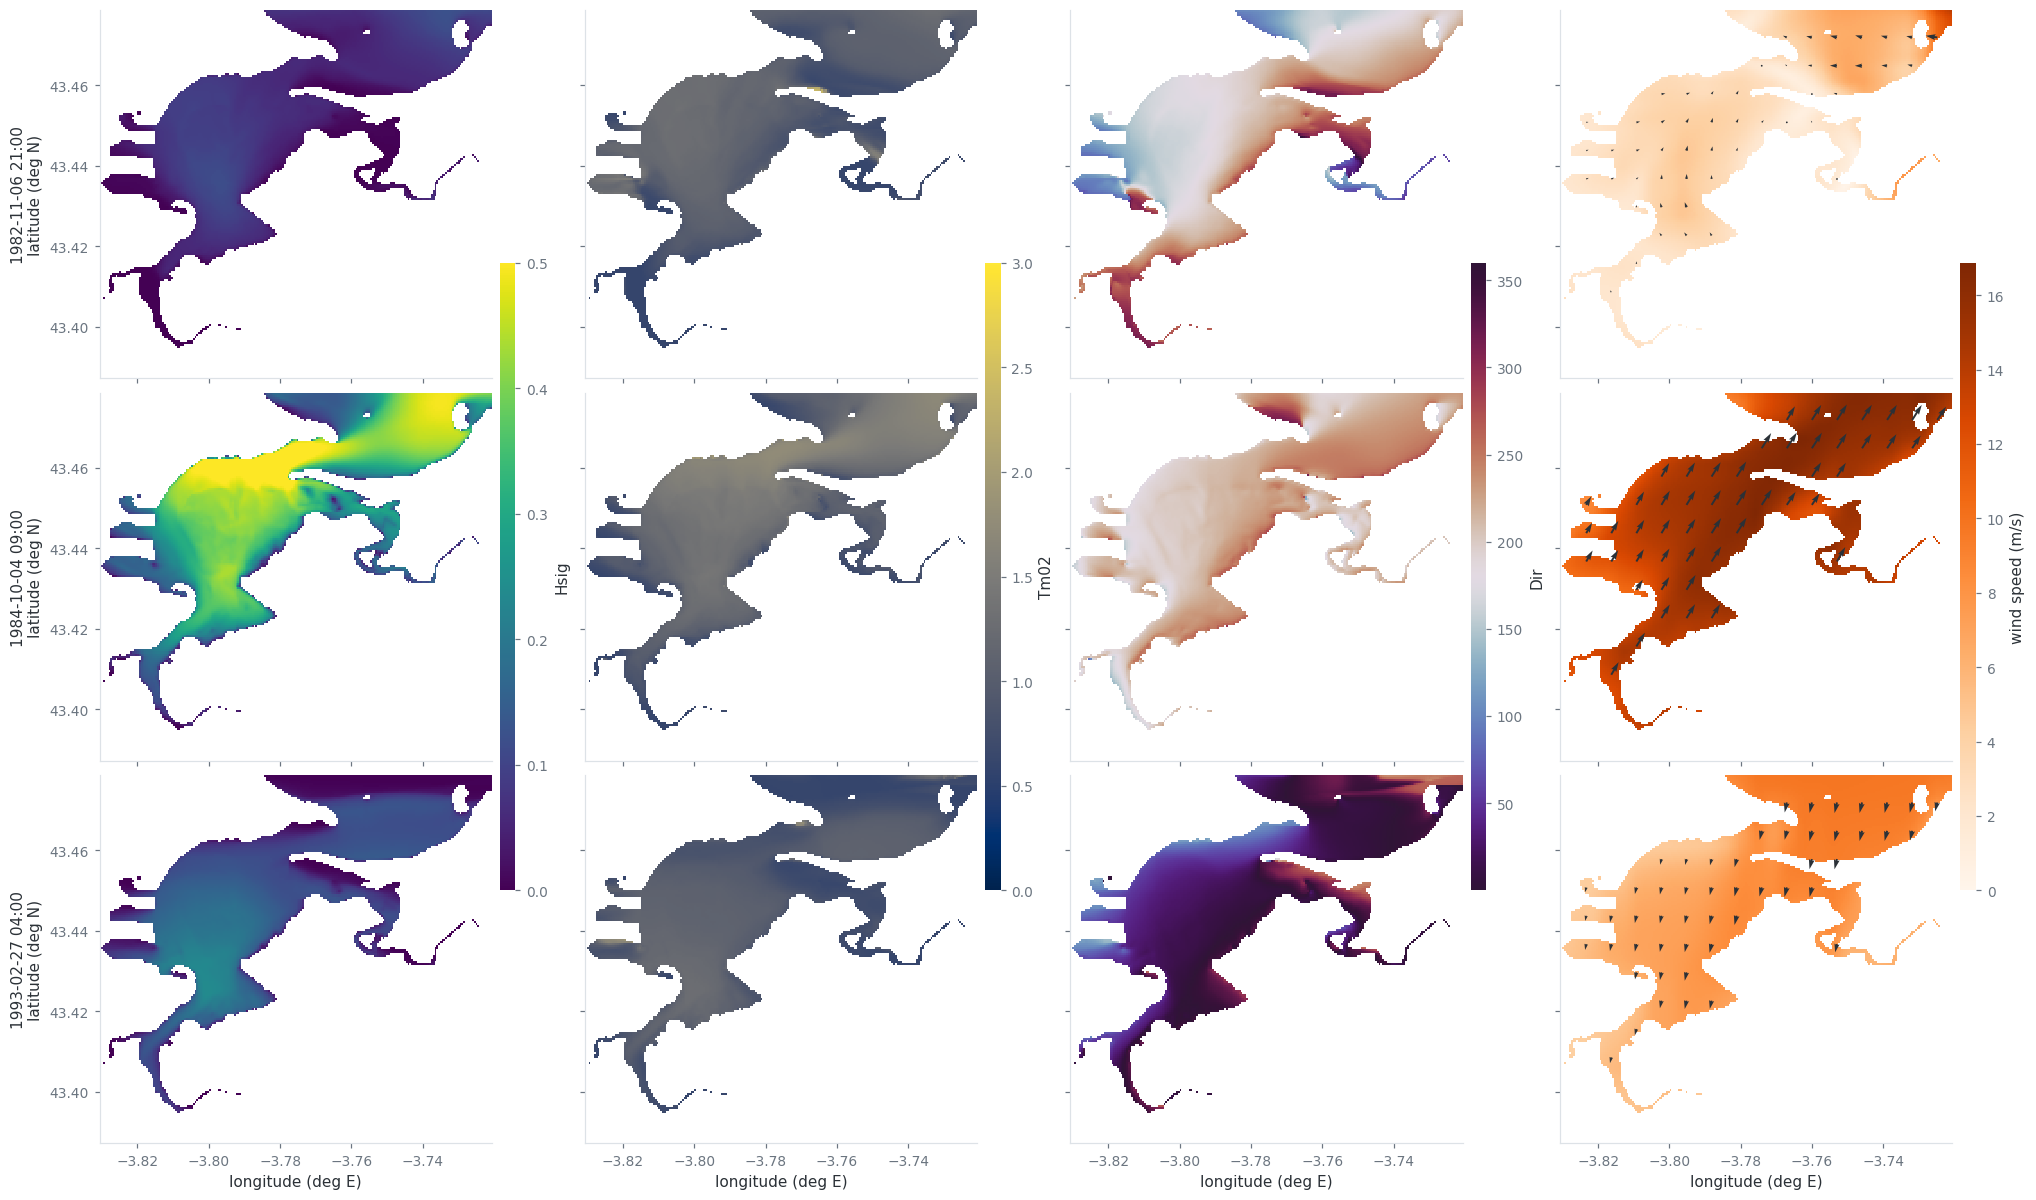

In [16]:
plot_wave_examples(
    ds_wave_final.isel(tide=0),
    time_indices=[0, 1, 2],
    wind=wind_hr,
    vmin_dict={"Hsig": 0, "Tm02": 0},
    vmax_dict={"Hsig": 0.5, "Tm02": 3},
);